# Домашнее задание 5. Генеративные модели


В этом ноутбуке мы будем работать с одной и той же задачей (генерация и реконструкция изображений),
сравнивая поведение классического автоэнкодера и вариационного автоэнкодера.

Домашнее задание опирается на материалы по автоэнкодерам, вариационным автоэнкодерам и латентным
переменным, а также продолжает линию лекции по генеративным моделям.

## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

- Простые задачи: 1–4.
- Средние задачи: 5–7.
- Сложные задачи: 8–9.

Во всех задачах мы работаем с одной и той же постановкой: учимся сжимать и восстанавливать изображения,
а затем сравниваем свойства AE и VAE.


## Теоретическая часть

### Автоэнкодер (AE)

Автоэнкодер — это нейросеть, которая принимает на вход объект (например, изображение),
сжимает его в латентный вектор фиксированной размерности, а затем восстанавливает обратно.

Состоит из двух частей:

- **Энкодер** отображает входной вектор в латентное представление меньшей размерности.
- **Декодер** восстанавливает объект из латентного вектора.

Модель обучается минимизировать ошибку реконструкции (насколько сильно восстановленное изображение
отличается от исходного). Это делает автоэнкодер хорошим инструментом для сжатия, денойзинга
и выделения признаков, но он не задает явную вероятностную модель данных.

### Вариационный автоэнкодер (VAE)

Вариационный автоэнкодер накладывает на латентное пространство вероятностную структуру.
Вместо одного латентного вектора для каждого объекта он учит распределение в латентном пространстве
(обычно многомерное нормальное с параметрами среднее и дисперсия).

Обучение осуществляется по нижней оценке правдоподобия (ELBO), которая одновременно:

- поощряет хорошую реконструкцию объектов;
- прижимает распределение скрытых переменных к простому априорному распределению.

Благодаря этому VAE умеет как реконструировать данные, так и генерировать новые правдоподобные
примеры, отбирая точки напрямую из латентного распределения.

### Наша экспериментальная схема

В этом домашнем задании:

- мы используем один и тот же датасет изображений;
- обучаем на нем простой автоэнкодер;
- обучаем на нем вариационный автоэнкодер с той же архитектурой энкодера и декодера;
- сравниваем качество реконструкции, структуру латентного пространства и сгенерированные семплы.

Логика: Теория → Гипотеза → Эксперимент → Интерпретация.

После решения каждой задачи не забудьте заполнить поле «Интерпретация».


## Настройка окружения

In [1]:
# Импорты
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Фиксация генераторов случайных чисел
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {DEVICE}")


Используемое устройство: cuda


## Подготовка данных

В качестве базовой задачи будем использовать простой датасет изображений цифр (MNIST).

Что сделаем:

- загрузим обучающую и тестовую выборки;
- нормализуем изображения в диапазон от 0 до 1;
- подготовим функции визуализации батча и реконструкций.


In [2]:
# Загрузка датасета MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Размер обучающей выборки: {len(train_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")


Размер обучающей выборки: 60000
Размер тестовой выборки: 10000


In [3]:
import torchvision  # импортируем здесь для функций визуализации

In [4]:
# Вспомогательная функция для визуализации батча изображений

def show_images(images, title="Примеры изображений", nrow=12):
    images = images.detach().cpu()
    grid = torch.clone(images[: nrow * nrow])
    fig, ax = plt.subplots(figsize=(nrow, 8))
    grid = torchvision.utils.make_grid(grid, nrow=8, pad_value=1.0, padding=8)
    ax.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    ax.axis("off")
    plt.show()


---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

Эти задачи направлены на базовое понимание того, как выглядят данные,
как устроен автоэнкодер и как оценивать его реконструкции.


## Задача 1. Загрузка и визуализация данных

### Постановка задачи

Загрузить обучающую выборку изображений цифр, посмотреть на форму тензоров
и визуализировать несколько примеров.

### Теоретический минимум

- Каждый объект представлен как изображение 28×28 пикселей в оттенках серого.
- Для подачи в полносвязную сеть изображения часто разворачивают в вектор длины 784.
- Важно убедиться, что данные нормализованы и имеют ожидаемую форму.


Форма батча изображений: torch.Size([128, 1, 28, 28])
Форма батча меток: torch.Size([128])


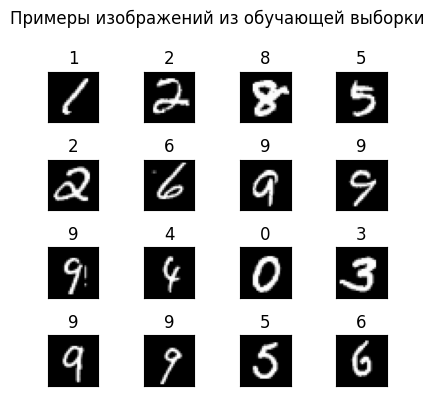

In [5]:
# Задача 1. Загрузка и визуализация данных

def show_images_1(images, labels, title="Примеры изображений", nrow=8):
    images = images.detach().cpu()
    labels = labels.detach().cpu()  # добавил метки
    # grid = torch.clone(images[: nrow * nrow])
    fig, axes = plt.subplots(nrow, nrow, figsize=(nrow, nrow))
    axes = axes.flatten()  # плоский для удобства перебора в цикле
    # grid = torchvision.utils.make_grid(grid, nrow=nrow, pad_value=1.0)
    num_images = min(images.shape[0], nrow * nrow)
    for n_i in range(num_images):
        axes[n_i].imshow(images[n_i].squeeze(), cmap="gray")
        axes[n_i].set_xticks([])
        axes[n_i].set_yticks([])
        axes[n_i].set_title(str(labels[n_i].item()))  # метки к каждой картинке
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# Получите один батч из train_loader
images, labels = next(iter(train_loader))

# DONE: Выведите форму батча
print("Форма батча изображений:", images.shape)  # (batch,channels,height,width)
print("Форма батча меток:", labels.shape)

# DONE: Визуализируйте 16 примеров с помощью show_images()
show_images_1(images,
            labels,
            title="Примеры изображений из обучающей выборки",
            nrow=4)

**Интерпретация:**  
- в датасете `MNIST` 70_000 рукописных (или около того) изображений цифр от 0 до 9. Каждое изображение содержит 784 пикселя и имеет форму 1x28x28(Кол-воКаналов X Высота X Ширина). размер `train = 60_000` изображений, `test` соответственно `10_000`
- Канал несёт в себе информацию о цвете: 3 канала - RGB цвет(цветное); 1 канал - Gray(интенсивность церного цвета или свечение пикселя)
- я изменил функцию `show_images()` так, чтобы она отображала метки изображений как в output шаблона Задачи 1  
- `torchvision.utils.make_grid()` склеивал изображение в одно целое, я не мог добавить метки к каждому изображени. Пришлось закомментировать  
- также пришлось добавить цикл для сопоставления `labels` с `images`  

Я вывожу 16 рукописных изображений. Каждому изображению сопоставлена соответствующая метка в виде цифры. `torchvision.utils.make_grid()` выводит все 16 изображений, но делает это в одном едином изображении (склеивает их), вследствие чего я не смог сопоставить `labels` с `images`. Пришлось модифицировать функцию `show_images` в `show_images1`.  

Одно изображение имеет форму (batch, channels, height, width), где:
  - `batch` == `BATCH_SIZE` (задали в `DataLoader`)
  - `channels` == 1 (один канал пикселя в изображении - черный)
  - `height` (высота изображения)  
  - `width` (ширина изображения)  

## Задача 2. Реализация и обучение простого автоэнкодера

### Постановка задачи

Реализовать простой полносвязный автоэнкодер для изображений цифр:

- энкодер: несколько линейных слоев, сжимающих изображение в латентный вектор фиксированной размерности;
- декодер: несколько линейных слоев, восстанавливающих изображение из латентного вектора.

Обучить автоэнкодер на обучающей выборке и визуально оценить качество реконструкций.

### Теоретический минимум

- Автоэнкодер минимизирует ошибку реконструкции (MSE или бинарную кросс-энтропию).
- Латентное пространство может иметь гораздо меньшую размерность, чем исходное изображение.
- Качественный автоэнкодер должен уметь восстанавливать основные структуры (контуры цифр).


Эпоха 1/5, loss = 0.0482
Эпоха 2/5, loss = 0.0208
Эпоха 3/5, loss = 0.0152
Эпоха 4/5, loss = 0.0127
Эпоха 5/5, loss = 0.0113


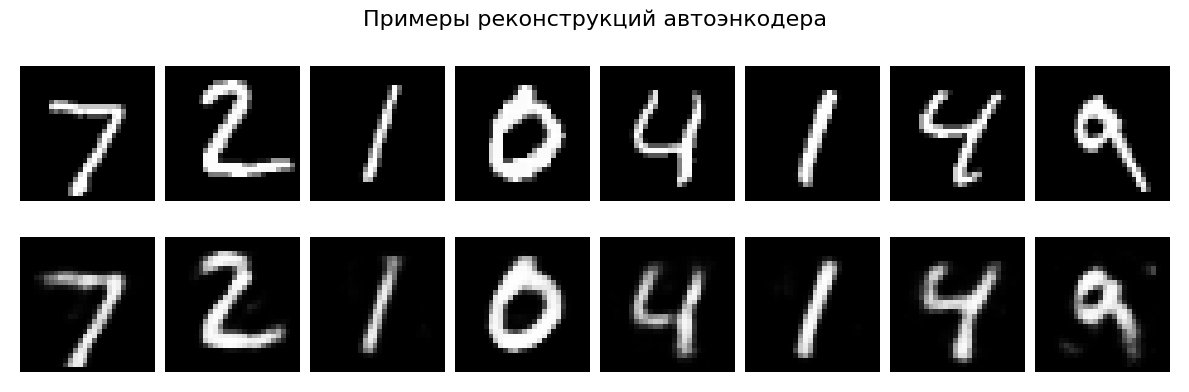

In [6]:
# Задача 2. Реализация и обучение простого автоэнкодера

class SimpleAutoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        hidden_layer_size = 128  # количество нейронов скрытого слоя
        n_pixels = 28 * 28

        # DONE: Определите encoder
        # n_pixels(784) -> hidden_layer_size(128) -> latent_dim(32)
        self.encoder = nn.Sequential(
            nn.Linear(n_pixels, hidden_layer_size),
            nn.ReLU(),  # защищаемся от затухания градиентов
            nn.Linear(hidden_layer_size, latent_dim)
        )

        # DONE: Определите decoder
        # latent_dim(32) -> hidden_layer_size(128) -> n_pixels(784)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_layer_size),
            nn.ReLU(),
            nn.Linear(hidden_layer_size, n_pixels),
            # нормирую в [0, 1] т.к. в сути предсказываем значения от 0 до 1
            nn.Sigmoid()
        )

    def forward(self, x):
        # DONE: Forward pass
        # вход x: (batch,channels,height,width)
        b, c, h, w = x.shape
        x = torch.flatten(x, start_dim=1)  # делаю x плоским: (batch,c*h*w)
        z = self.encoder(x)  # кодирую
        x_recon = self.decoder(z) # декодирую
        return x_recon.view(b, c, h, w)  # восстанавливаю форму


# ============================ Фиксирую случайность ============================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# DONE: Создайте модель
model = SimpleAutoencoder(latent_dim=32).to(DEVICE)

# DONE: Определите loss и optimizer
loss_criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# DONE: Обучите модель
# ================================= Обучение AE ================================
train_losses = []
epochs = 5
for epoch in range(1, epochs+1):
    model.train()
    losses = []
    # оценка качества
    for images, labels in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()  # не учитывае градиенты
        out_images = model(images)
        loss = loss_criterion(out_images, images)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    train_losses.append(sum(losses) / len(losses))
    print(f"Эпоха {epoch}/{epochs}, loss = {train_losses[-1]:.4f}")


# ==================== Получаю предсказание на первом батче ====================
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(DEVICE)
    recon_images = model(test_images)


# ================================ Визуализация ================================
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
n_imgs = 8

# ==================== Оригинальные изображения (строка 1) =====================
orig_grid = torchvision.utils.make_grid(
    test_images[:n_imgs],
    nrow=n_imgs,
    pad_value=1.
)
axes[0].imshow(
    orig_grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)
# =================== Реконструкция изображений (строка 2) =====================
recon_grid = torchvision.utils.make_grid(
    recon_images[:n_imgs],
    nrow=n_imgs,
    pad_value=1.
)
axes[1].imshow(
    recon_grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)

axes[0].axis("off"); axes[1].axis("off")

fig.suptitle("Примеры реконструкций автоэнкодера", size=16, y=0.82)
plt.subplots_adjust(hspace=-0.6); plt.tight_layout(); plt.show()


**Интерпретация:**

Автоэнкодер `SimpleAutoencoder()` _в процессе подгонки_ выполняет преобразование полного изображения в латентный вектор, содержащий в себе всю необходимую информацию о значимых пикселях изображения. Это показывает, что в изображении существуют пиксели, содержащие незначительную информацию, а значительные пиксели могут быть представлены в более низкоразмерном пространстве. Длина латентного вектора `latent_dim`, влияет на количество содержащейся в этом векторе полезной информации. **Чем длиннее вектор**, тем выше риск переобучиться и наоборот. _После подгонки модели_ происходит обратное преобразование: `latent_dim(32) -> hidden_layer_size(128) -> n_pixels(784)`  

После преобразования, на визуализациях, видны основные формы цифр, но мелкие детали могут быть сглаженными или икаженными. Это естественно для полносвязного автоэнкодера — он не использует пространственную структуру (свёртки).  

`Sigmoid` в `decoder` необходима, чтобы выходные пиксели лежали в том же диапазоне, что и входные ([0,1]). Без `Sigmoid` реконструкция может выходить за пределы диапазона интенсивности свечения пиксей, что однозначно ухудшит визуальное качество и сходимость.  

`.flatten()` и `.reshape()` я использую для того, чтобы правильно обработать размерности входной/выходной последовательностей, поскольку полносвязные слои работают только с векторами, поэтому перед энкодером изображение делается "плоским, а после декодера - исходной формы.  


## Задача 3. Анализ динамики ошибки автоэнкодера

### Постановка задачи

Построить график ошибки реконструкции автоэнкодера по эпохам обучения
и проинтерпретировать его.

### Теоретический минимум

- Убывание ошибки по эпохам говорит о том, что модель успешно обучается.
- Плато или рост ошибки могут сигнализировать о переобучении или проблемах с оптимизацией.


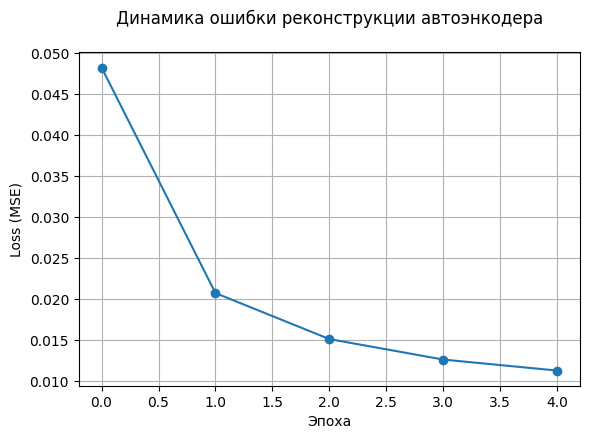

In [7]:
# Задача 3. Анализ динамики ошибки автоэнкодера

# DONE: Постройте график ошибки по эпохам
plt.figure(figsize=(6, 4.5))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.xlabel("Эпоха")
plt.ylabel("Loss (MSE)")
plt.title("Динамика ошибки реконструкции автоэнкодера", y=1.06)
plt.grid(); plt.tight_layout(); plt.show()

# DONE: Проанализируйте график

**Интерпретация:**
 - **0 эпоха**: веса `decoder` и `encoder` инициализированы случайными весами, ошибка максимальная;  
 - **1 эпоха**: модель учится распознавать и реконструировать изображения, улавливая основную информацию, содержащуюся в латентном слое;  
 - **2 эпоха**: всё еще учится;  
 - **3 эпоха**: модель практически готова выйти на "плато", однако ошибка продолжает снижаться. Возможно мы выйдем на "плато" с увеличением количества эпох при обучении модели, однако в этом случае модель переобучится;  
 - **4 эпоха**: минимальное значение ошибки среди всех эпох.  

## Задача 4. Визуализация латентного пространства автоэнкодера

### Постановка задачи

Обучить вариант автоэнкодера с двумерным латентным пространством и
визуализировать распределение латентных векторов для тестовой выборки,
окрашивая точки по истинным классам цифр.

### Теоретический минимум

- Двумерное латентное пространство удобно для визуализации.
- Кластеры в латентном пространстве могут соответствовать разным классам данных.


[2D AE] Эпоха 1/8, loss = 0.0632
[2D AE] Эпоха 2/8, loss = 0.0515
[2D AE] Эпоха 3/8, loss = 0.0495
[2D AE] Эпоха 4/8, loss = 0.0483
[2D AE] Эпоха 5/8, loss = 0.0474
[2D AE] Эпоха 6/8, loss = 0.0467
[2D AE] Эпоха 7/8, loss = 0.0463
[2D AE] Эпоха 8/8, loss = 0.0458


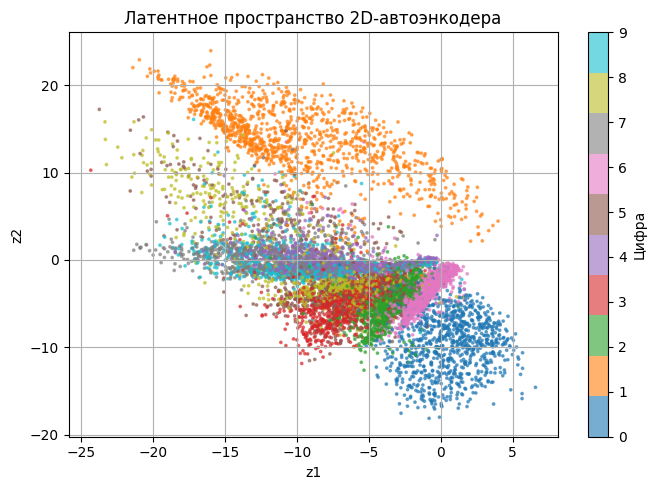

In [8]:
# Задача 4. Визуализация латентного пространства автоэнкодера

class AutoencoderLatent2D(SimpleAutoencoder):
    def __init__(self, latent_dim):
        super().__init__(latent_dim=latent_dim)


# ============================ Фиксирую случайность ============================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# DONE: Обучите модель с latent_dim=2 ==========================================
ae_2d = AutoencoderLatent2D(latent_dim=2).to(DEVICE)
optimizer = torch.optim.Adam(ae_2d.parameters(), lr=1e-3)

train_losses = []
epochs = 8
for epoch in range(1, epochs+1):
    ae_2d.train()
    losses = []
    for images, _ in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()
        out_images = ae_2d(images)
        loss = loss_criterion(out_images, images)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    train_losses.append(sum(losses) / len(losses))
    print(f"[2D AE] Эпоха {epoch}/{epochs}, loss = {train_losses[-1]:.4f}")

# DONE: Получите латентные представления для test_dataset ======================
latents = []
labels_list = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        z = ae_2d.encoder(images.view(images.shape[0], -1))
        latents.append(z.cpu())  # с cuda на cpu
        labels_list.append(labels)
latents_tensor = torch.cat(latents, dim=0)
labels_tensor = torch.cat(labels_list, dim=0)

# DONE: Визуализируйте scatter plot ============================================
plt.figure(figsize=(7, 5))
sc = plt.scatter(
    latents_tensor[:, 1],
    latents_tensor[:, 0],
    c=labels_tensor,
    cmap="tab10",
    alpha=0.6,
    s=3
)
plt.colorbar(sc, label="Цифра")
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Латентное пространство 2D-автоэнкодера")
plt.grid()
plt.tight_layout()
plt.show()

**Интерпретация:**

 - в ТУДУшке было указано `# DONE: Получите латентные представления для test_dataset`, восприму эту ТУДУшку как ошибку, поскольку у нас есть `test_loader` и `test_dataset` использовать не рационально  

Для построения `AutoencoderLatent2D` я наследовал `SimpleAutoencoder` с возможностью передачи параметра `latent_dim`. Энкодер и декодер в `AutoencoderLatent2D` остаются полносвязными с одним скрытым слоем. Размер скрытого слоя должен быть одинаковым для энкодера и декодера.  

Для чёткой кластеризации изображений нужно минимум 8 эпох, в противном случае (на 3-х эпохах) на модели `AutoencoderLatent2D` мы получем плато с значениями MAE 0.045 и незначительно вниз (плато) с 8й эпохи.  

**Награфике** латентное пространство не центрировано и может иметь произвольный сдвиг. Разброс кластеров зависит от числа эпох (как я заметил ранее), инициализации и размера скрытого слоя. Кластеры не обязаны быть компактными или симметричными (из интернетов).  

Перепутанные классы (например, 4 и 9, 8 и 3 близко) - типично __для простого автоэнкодера__, так как __он не стремится разделять классы, а лишь минимизирует MSE__  

Для наиболее лучшего разделения классов по кластерам необходимо увеличить размер латентного пространства  

---

# СРЕДНИЕ ЗАДАЧИ (5–7)

В этих задачах мы реализуем вариационный автоэнкодер и сравним его с обычным AE
по реконструкции и поведению в латентном пространстве.

## Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

### Постановка задачи

Реализовать вариационный автоэнкодер со схожей архитектурой энкодера и декодера,
как у автоэнкодера, и обучить его на тех же данных.

### Теоретический минимум

- Энкодер VAE предсказывает среднее и разброс распределения в латентном пространстве.
- В латентном слое мы семплируем случайный вектор на основе этих параметров.
- Функция потерь VAE сочетает ошибку реконструкции и регуляризацию латентного пространства.


[VAE] Эпоха 1/5, total=7023.9867, rec=6453.0034, kl=570.9833
[VAE] Эпоха 2/5, total=5261.5876, rec=4334.2881, kl=927.2996
[VAE] Эпоха 3/5, total=4799.3779, rec=3700.1969, kl=1099.1810
[VAE] Эпоха 4/5, total=4527.2185, rec=3345.8475, kl=1181.3710
[VAE] Эпоха 5/5, total=4385.2324, rec=3158.1295, kl=1227.1029


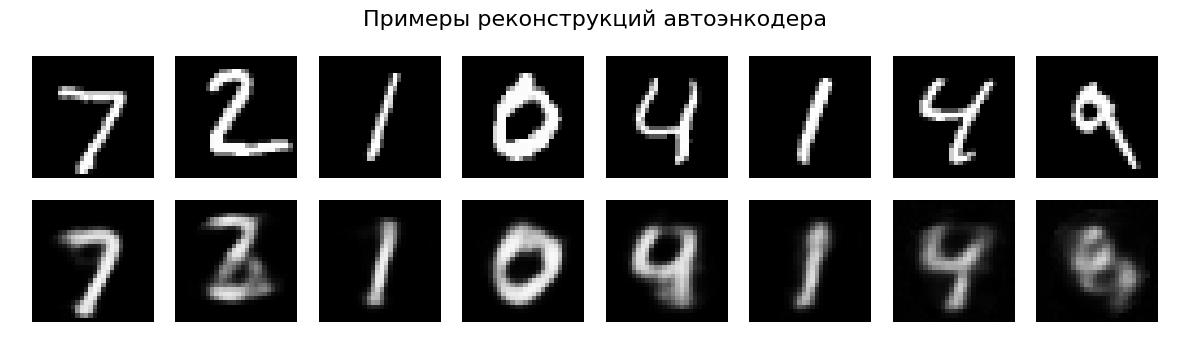

In [9]:
# Задача 5. Реализация и обучение вариационного автоэнкодера (VAE)

class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        hidden_layer_size = 128  # количество нейронов скрытого слоя
        n_pixels = 28 * 28

        # DONE: Encoder
        # n_pixels(784) -> hidden_layer_size(128) -> latent_dim(32)
        self.encoder = nn.Sequential(
            nn.Linear(n_pixels, hidden_layer_size),
            nn.ReLU(),  # защищаемся от затухания градиентов
        )
        # DONE: Mu и logvar слои
        self.fc_mu = nn.Linear(hidden_layer_size, latent_dim)
        self.fc_logvar = nn.Linear(hidden_layer_size, latent_dim)

        # DONE: Decoder
        # latent_dim(32) -> hidden_layer_size(128) -> n_pixels(784)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_layer_size),
            nn.ReLU(),
            nn.Linear(hidden_layer_size, n_pixels),
            # нормирую в [0, 1] т.к. в сути предсказываем значения от 0 до 1
            nn.Sigmoid()
        )

    def encode(self, x):
        # DONE: Получите mu и logvar
        h = self.encoder(x)  # активировались, получили скрытый слой
        return self.fc_mu(h), self.fc_logvar(h)

    def _reparameterize(self, mu, logvar):
        # DONE: Трюк репараметризации
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def forward(self, x):
        # DONE: Full forward pass
        b, c, h, w = x.shape
        x_flat = x.view(b, -1)
        mu, logvar = self.encode(x_flat)
        z = self._reparameterize(mu, logvar)
        x_recon_flat = self.decoder(z)
        x_recon = x_recon_flat.view(b, c, h, w)  # приводим к shape x
        return x_recon, mu, logvar


# ============================ Фиксирую случайность ============================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# DONE: Создайте и обучите VAE
# ========================== Создание и обучение VAE ===========================
vae = VAE(latent_dim=64).to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

epochs = 5
for epoch in range(1, epochs+1):
    vae.train()
    losses = [0., 0., 0.]  # losses: (total: float, rec: float, kl: float)
    batches = 0
    for images, _ in train_loader:
        images = images.to(DEVICE)
        optimizer.zero_grad()
        rec, mu, logvar = vae(images)
        rec_loss = F.mse_loss(rec, images, reduction="sum")
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        elbo = rec_loss + kl_loss
        elbo.backward()
        optimizer.step()
        losses[0] += elbo.item()
        losses[1] += rec_loss.item()
        losses[2] += kl_loss.item()
        batches += 1
    print(f"[VAE] Эпоха {epoch}/{epochs}, " + 
          f"total={losses[0] / batches:.4f}, " +
          f"rec={losses[1] / batches:.4f}, " + 
          f"kl={losses[2] / batches:.4f}")

# DONE: Используйте ELBO loss

# ==================== Получаю предсказания на первом батче ====================
model.eval()
with torch.no_grad():
    vae_recon, _, _ = vae(test_images)

# ================================ Визуализации ================================
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
n_imgs = 8

# ==================== Оригинальные изображения (строка 1) =====================
orig_grid = torchvision.utils.make_grid(
    test_images[:n_imgs],
    nrow=n_imgs,
    pad_value=1.,
    padding=5
)
axes[0].imshow(
    orig_grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)
# ==================== VariationalAutoencoder (строка 2) =======================
vae_recon_grid = torchvision.utils.make_grid(
    vae_recon[:n_imgs],
    nrow=n_imgs,
    pad_value=1.,
    padding=5
)
axes[1].imshow(
    vae_recon_grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)

axes[0].axis("off"); axes[1].axis("off")

fig.suptitle("Примеры реконструкций автоэнкодера", size=16, y=0.68)
plt.subplots_adjust(hspace=-1.); plt.tight_layout(); plt.show()

**Интерпретация:**

Заметки для себя:
 - `mu(среднее)` и `logvar(логарифм дисперсии)` - это два линейных слоя без активации на выходе. Нужно это чтобы параметры распределения были неограничены, из этого распределения с помощью репараметризации `elbo` сэмплируется латентный вектор z = mu + exp(0.5 * logvar) * eps.


 - репараметризация `std = torch.exp(0.5 * logvar)` и  `z = mu + eps * std` позволяет градиенту проходить через сэмплирование, т.е. градиенты потерь могут быть распространены обратно в энкодер для обновления mu и logvar, что позволяет обучать VAE с помощью обычного стохастического градиентного спуска  

 - что VAE не копирует, а генерирует правдоподобные изображения, но пока размытые  
 
 - (из интернетов) баланс между `recon` и `kl` - если KL **слишком мал**, то латентное пространство не регуляризовано; если **слишком велик**, реконструкция слишком размытая  

 - слишком маленький размер латентного пространства `latent_dim` приводит к размытым реконструкциям, слишком большой к переобучению.

Изображения, полученные через `VAE` достаточно размытые по трём причинам:
 1. `KL-регуляризация` заставляет латентное пространство быть гладким и непрерывным: векторы разных примеров должны перекрываться. Это приводит к тому, что декодер обучается отображать не точный латентный вектор одного изображения, а целую область, усредняя и "размазывая" детали  
 2. `репараметризация` - на вход декодера подаётся не фиксированный `mu`, а `z = mu + шум`. Декодер учится быть устойчивым к этим вариациям, что сглаживает резкие переходы в пикселях  
 3. `функция потерь (MSE)` штрафует за среднеквадратичное отклонение, что также ведёт к усреднению возможных вариантов (оптимальная реконструкция при MSE - это среднее арифметическое по всем возможным выходам). В отличие от обычного автоэнкодера, который может запомнить конкретное изображение, VAE вынужден восстанавливать изображения из "размытого" распределения.

__Мне не удалось добиться цифр, выведенных для образца__, однако суть я уловил: если KL **слишком мал**, то латентное пространство не регуляризовано; если **слишком велик**, реконструкция слишком размытая. Нужно искать баланс  

## Задача 6. Сравнение реконструкций AE и VAE на одних и тех же примерах

### Постановка задачи

Построить визуальное сравнение реконструкций автоэнкодера и вариационного автоэнкодера
на одних и тех же изображениях.

### Теоретический минимум

- AE стремится максимально точно копировать вход.
- VAE может жертвовать точностью ради более гладкого латентного пространства.


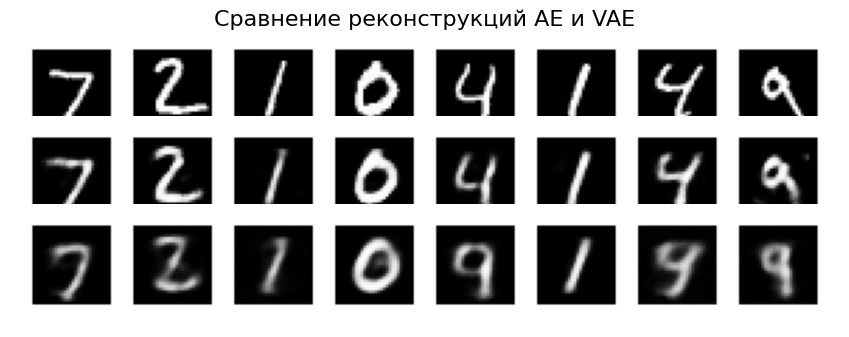

In [10]:
# Задача 6. Сравнение реконструкций AE и VAE

# DONE: Получите реконструкции из обеих моделей
with torch.no_grad():
    ae_recon = model(test_images)
    vae_recon, _, _ = vae(test_images)

# DONE: Визуализируйте сравнение
# ================================ Визуализации ================================
fig, axes = plt.subplots(3, 1, figsize=(8.6, 6))
n_imgs = 8

# ============================ Строка 1: Оригиналы =============================
orig_grid = torchvision.utils.make_grid(
    test_images[:n_imgs],
    nrow=n_imgs,
    pad_value=1.,
    padding=8
)
axes[0].imshow(
    orig_grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)
# ======================== Строка 2: AE реконструкции ==========================
ae_recon_grid = torchvision.utils.make_grid(
    ae_recon[:n_imgs],
    nrow=n_imgs,
    pad_value=1.,
    padding=8
)
axes[1].imshow(
    ae_recon_grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)
# ======================= Строка 3: VAE реконструкции ==========================
vae_recon_grid = torchvision.utils.make_grid(
    vae_recon[:n_imgs],
    nrow=n_imgs,
    pad_value=1.,
    padding=8
)
axes[2].imshow(
    vae_recon_grid.permute(1, 2, 0).cpu().squeeze(),
    cmap="gray"
)

axes[0].axis("off"); axes[1].axis("off"); axes[2].axis("off")

fig.suptitle("Сравнение реконструкций AE и VAE", size=16, y=0.75)
plt.subplots_adjust(hspace=-0.9); plt.tight_layout(); plt.show()

**Интерпретация:**

В общем, `в выводах к Задаче 5` всё объяснил, тут нечего добавить

## Задача 7. Интерполяция в латентном пространстве VAE

### Постановка задачи

Взять два разных изображения из тестовой выборки, получить их латентные коды в VAE
и построить интерполяцию между ними. Визуализировать, как плавно меняется картинка
при движении по отрезку в латентном пространстве.

### Теоретический минимум

- В хорошо устроенном латентном пространстве небольшие изменения латентного кода
  приводят к плавным и осмысленным изменениям сгенерированного объекта.


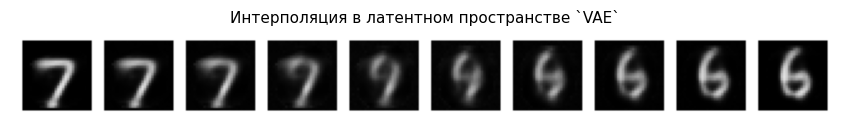

In [11]:
# Задача 7. Интерполяция в латентном пространстве VAE

# DONE: Возьмите два изображения
img1, img2 = test_dataset[0][0], test_dataset[21][0]

# DONE: Получите их латентные коды
vae.eval()  # получаю латентные коды на обученном vae
with torch.no_grad():
    mu1, _ = vae.encode(img1.view(1, -1).to(DEVICE))  # плоский в CUDA
    mu2, _ = vae.encode(img2.view(1, -1).to(DEVICE))

# DONE: Интерполируйте
alphas = torch.linspace(0, 1, steps=10).to(DEVICE)

# Соберу все изображения в список и выведу через torchview
images_list = []
for alpha in alphas:
    z_interp = (1 - alpha) * mu1 + alpha * mu2
    x_interp_flat = vae.decoder(z_interp)  # x_interp_flat: (1, 784)
    # print(x_interp_flat.shape)
    x_interp = x_interp_flat.view(1, 1, 28, 28)  # x_interp: (1, 1, 28, 28)
    images_list.append(x_interp)


all_images = torch.cat(images_list, dim=0)  # all_images: (10, 1, 28, 28)
inter_grid = torchvision.utils.make_grid(
    all_images,
    nrow=10,
    pad_value=1.0,
    padding=5
)

# Отображаем
plt.figure(figsize=(8.6, 6))
plt.imshow(inter_grid.permute(1, 2, 0).cpu().squeeze(),
           cmap="gray")
plt.axis("off")
plt.title("Интерполяция в латентном пространстве `VAE`", size=11, y=0.98)
plt.tight_layout(); plt.show()

**Интерпретация:**

Плавно преобразовались от `7` не  то в `9`, затем в `6`  
**Вывод:**
 - плавное изменение значений латентного вектора (движение по прямой от одного изображения к другому) приводит к плавным и осмысленным изменениям на выходе модели - это говорит о том, что `VAE` выучил не просто сжатие, а хорошо структурированное латентное представление  

 - в отличие от обычного `AE`, который может давать резкие скачки при интерполяции, `VAE` создаёт промежуточные "осмысленные" изображения, которых не было в обучающей выборке  

---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

Теперь нас интересуют генерация новых примеров и более формальное сравнение
качества автоэнкодера и вариационного автоэнкодера.

## Задача 8. Генерация новых примеров из латентного пространства

### Постановка задачи

Сгенерировать набор новых изображений, не встречавшихся в обучающей выборке,
используя:

- выборку латентных векторов из простого распределения;
- декодер VAE для получения изображений.

Сравнить разнообразие и правдоподобие полученных картинок.

### Теоретический минимум

- В VAE латентное пространство подгоняется под стандартное нормальное распределение.
- Это позволяет генерировать новые данные, просто выбирая случайные точки в латентном пространстве.


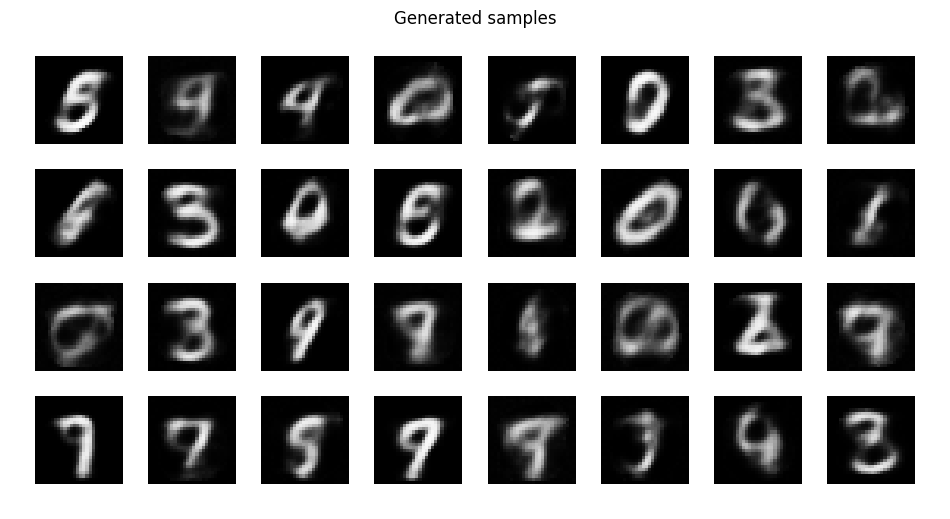

In [12]:
# Задача 8. Генерация новых примеров из латентного пространства

# DONE: Сгенерируйте случайные z из N(0, I)
z_samples = torch.randn(32, 64)  # 32 случайных изображения размерностью 64

# DONE: Декодируйте
with torch.no_grad():
    generated_flat = vae.decoder(z_samples.to(DEVICE))  # (32, 784)
    generated = generated_flat.view(-1, 1, 28, 28)  # (16, 1, 28, 28)

# DONE: Визуализируйте
show_images(generated.view(-1, 1, 28, 28), title="Generated samples")
# Задача 8: Генерация новых примеров с помощью VAE (решение)

**Интерпретация:**

`VAE` определённым образом может генерировать случайные изображения с числами. Причём среди 32х изображений наблюдаются попытки сгенерировать что-то промежуточное, как в `задаче 7`

**Это было самое простое задание =(** однако интересное =)

## Задача 9. Количественное сравнение AE и VAE

### Постановка задачи

Сравнить автоэнкодер и вариационный автоэнкодер по двум простым метрикам:

1. Средняя ошибка реконструкции на тестовой выборке.
2. Простая оценка разнообразия сгенерированных примеров.

### Теоретический минимум

- Ошибка реконструкции показывает, насколько модель хорошо запоминает и восстанавливает обучающую выборку.
- Разнообразие семплов показывает, насколько модель способна порождать много разных примеров.


In [13]:
# Задача 9. Количественное сравнение AE и VAE

# TODO: 1. Средняя ошибка реконструкции
# ae_mse = ...
# vae_mse = ...
# print(f"AE MSE: {ae_mse:.4f}")
# print(f"VAE MSE: {vae_mse:.4f}")

# TODO: 2. Оценка разнообразия
# Сгенерируйте 100 сэмплов из каждой модели
# Вычислите среднее попарное расстояние
# diversity_ae = ...
# diversity_vae = ...
# print(f"AE diversity: {diversity_ae:.4f}")
# print(f"VAE diversity: {diversity_vae:.4f}")


**Интерпретация:**


---

## Интерпретация результатов

В ходе домашнего задания мы увидели следующее:

- Обычный автоэнкодер хорошо восстанавливает входные изображения и дает низкую ошибку реконструкции,
  но его латентное пространство не имеет явной вероятностной структуры.
- Вариационный автоэнкодер вводит вероятностное латентное пространство и использует ELBO,
  чтобы одновременно учиться восстанавливать данные и упорядочивать скрытые представления.
- В визуальных сравнениях автоэнкодер дает более резкие реконструкции, тогда как VAE иногда сглаживает детали,
  но зато позволяет лучше интерполировать между объектами и легко генерировать новые примеры.
- Латентное пространство VAE оказывается более регулярным: интерполяции между точками выглядят плавно и осмысленно.
- При генерации из prior VAE естественным образом порождает правдоподобные объекты, в то время как AE
  при случайном выборе латентных векторов может выдавать менее реалистичные изображения.


## Выводы

1. Автоэнкодер — надежный инструмент для сжатия и реконструкции, но не полноценная вероятностная модель.
2. Вариационный автоэнкодер добавляет вероятностный слой и ELBO, что превращает его в генеративную модель,
   пригодную для порождения новых данных.
3. При сравнении на одной задаче AE выигрывает по точности реконструкции, но VAE выигрывает по структуре
   латентного пространства и возможностям генерации.
4. Выбор между AE и VAE зависит от цели: если важна точная реконструкция — используем AE; если нужны генерация
   и контролируемое латентное пространство — выбираем VAE.
5. На практике часто комбинируют идеи AE, VAE, GAN и диффузионных моделей, чтобы достичь баланса между
   качеством, стабильностью и выразительностью.


Доходчиво =( плюсую **++++**

9е задание, к сожалению, снова не успеваю. Тяжело идёт DL =(